TP 2 PLATEFORMES DE CONTENEURS

TP 20 - DOCKER

Installer docker : g5k-setup-docker -t : l'option -t permet de stocker les images docker dans le dossier /tmp/

docker run hello-world : 

In [ ]:
cchiaber@econome-22:/$ docker run hello-world
Unable to find image 'hello-world:latest' locally
latest: Pulling from library/hello-world
4f55086f7dd0: Pull complete 
d5e71e642bf5: Download complete 
Digest: sha256:5e23090353324d887c48ad5e5c56d294eab81588df9605b07d1afe895f9cc8f8
Status: Downloaded newer image for hello-world:latest

Hello from Docker!
This message shows that your installation appears to be working correctly.

To generate this message, Docker took the following steps:
 1. The Docker client contacted the Docker daemon.
 2. The Docker daemon pulled the "hello-world" image from the Docker Hub.
    (amd64)
 3. The Docker daemon created a new container from that image which runs the
    executable that produces the output you are currently reading.
 4. The Docker daemon streamed that output to the Docker client, which sent it
    to your terminal.

To try something more ambitious, you can run an Ubuntu container with:
 $ docker run -it ubuntu bash

Share images, automate workflows, and more with a free Docker ID:
 https://hub.docker.com/

For more examples and ideas, visit:
 https://docs.docker.com/get-started/

Installe une image docker (pull) sur un nouveau contenaier qui affiche sur le terminal "Hello from DOcker !", est un test de bonne instalation de Docker

TP-21-Minikube

In [ ]:
install minikube : 
curl -LO https://storage.googleapis.com/minikube/releases/latest/minikube-linux-amd64
sudo-g5k install minikube-linux-amd64 /usr/local/bin/minikube
minikube start
minikube status

In [ ]:
installe kubectl :

sudo-g5k apt-get install -y apt-transport-https ca-certificates curl gnupg
curl -fsSL https://pkgs.k8s.io/core:/stable:/v1.37/deb/Release.key | sudo-g5k gpg --yes --dearmor -o /etc/apt/keyrings/kubernetes-apt-keyring.gpg
sudo-g5k chmod 644 /etc/apt/keyrings/kubernetes-apt-keyring.gpg
echo 'deb [signed-by=/etc/apt/keyrings/kubernetes-apt-keyring.gpg] https://pkgs.k8s.io/core:/stable:/v1.37/deb/ /' | sudo-g5k tee /etc/apt/sources.list.d/kubernetes.list
sudo-g5k chmod 644 /etc/apt/sources.list.d/kubernetes.list
sudo-g5k apt-get update
sudo-g5k apt-get install -y kubectl

In [ ]:
cchiaber@econome-22:~$ kubectl get pods -A
NAMESPACE     NAME                               READY   STATUS    RESTARTS   AGE
kube-system   coredns-559f6c778d-bxsdq           1/1     Running   0          2m34s
kube-system   etcd-minikube                      1/1     Running   0          2m43s
kube-system   kindnet-5dpf2                      1/1     Running   0          2m34s
kube-system   kube-apiserver-minikube            1/1     Running   0          2m39s
kube-system   kube-controller-manager-minikube   1/1     Running   0          2m39s
kube-system   kube-proxy-89b6j                   1/1     Running   0          2m34s
kube-system   kube-scheduler-minikube            1/1     Running   0          2m43s
kube-system   storage-provisioner                1/1     Running   0          2m37s

kubectl get pods -A : Donne la liste des pods actifs (-A TOUT les pods) et depuis combien de temps ils sont lancés

In [ ]:
A l’aide de la documentation de kubectl, chercher une commande permettant de lister les noeuds et leur état : kubectl get nodes, kubectl describe node

In [ ]:
cchiaber@econome-22:~$ kubectl get nodes
NAME       STATUS   ROLES           AGE     VERSION
minikube   Ready    control-plane   4m31s   v1.37.0

TP-22-Jeu de Dés (Dice Roll)

In [ ]:
cchiaber@econome-22:~/public/TP2/Dossier TP-2X-20260915/22-NodeJS$ node test-dice-roller.js
{ Message: [ 4 ] }
{
  Message: [
    4, 1, 3, 4, 0,
    1, 5, 5, 4, 5
  ]
}

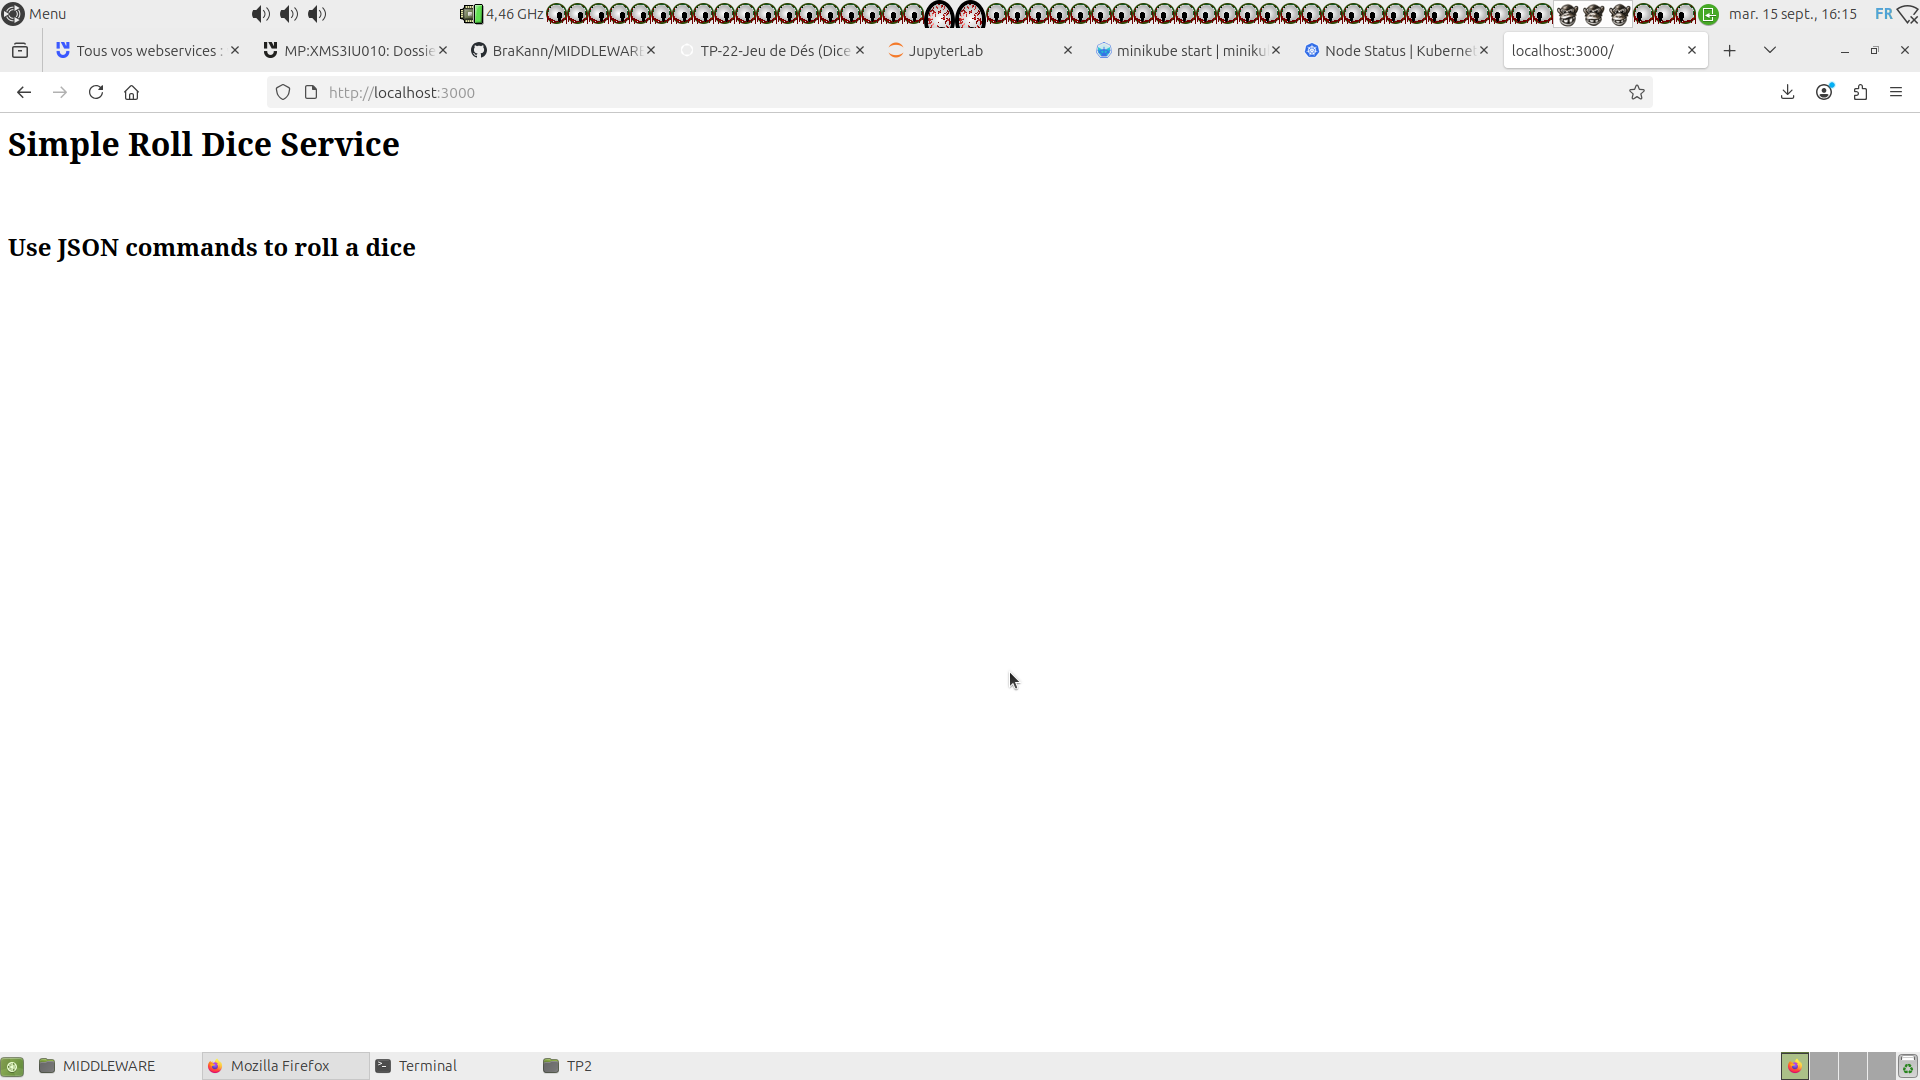

TP-23-DockerHub

Ouvrir le fichier Dockerfile et en examiner le contenu :

In [ ]:
FROM node:15

# Create app directory
WORKDIR /app

# Install app dependencies
# A wildcard is used to ensure both package.json AND package-lock.json are copied
COPY package*.json ./

RUN npm install

# Bundle app source
COPY main-dice-roller.js .

EXPOSE 3000

CMD [ "node", "main-dice-roller.js" ]

Ce conteneur creer un dossier app et installe les dependence necessaire au lancement du serveur main-dice-roller.js sur le port 3000, puis lance le serveur.

Construire une image docker pour votre application

docker build . --tag simple-roll-dice-service:v1
docker tag simple-roll-dice-service:v1 brakann/simple-roll-dice-service:v1
docker login
docker push brakann/simple-roll-dice-service:v1

Se connecter sur votre compte dockerhub, et vérifiez que l’image a bien été envoyée.

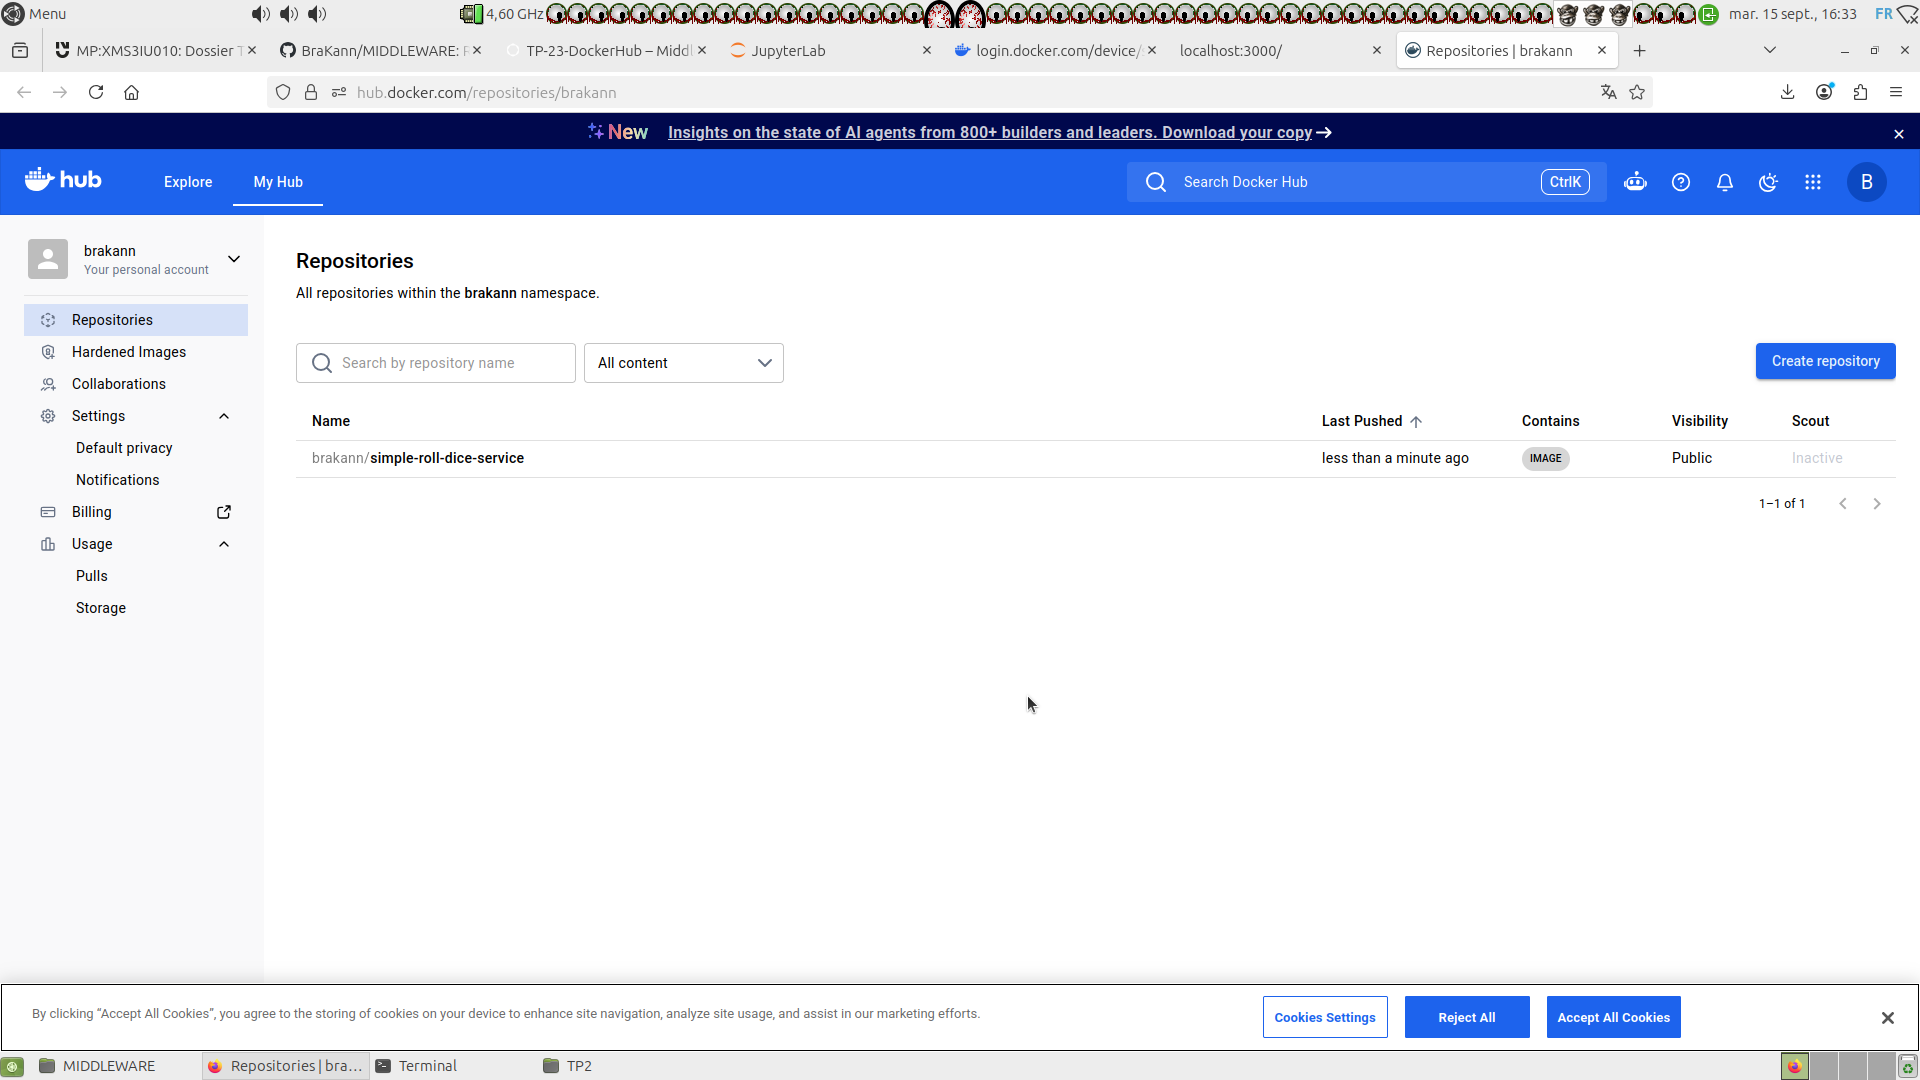

Démarrer un service depuis l’image docker stockée en ligne

run l'image et la redirige vers le port 3000 : sudo docker run --publish 3000:3000 --name simple-roll-dice-service --rm brakann/simple-roll-dice-service:v1

In [ ]:
cchiaber@econome-22:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ sudo docker run --publish 3000:3000 --name simple-roll-dice-service --rm brakann/simple-roll-dice-service:v1
node:internal/modules/cjs/loader:927
  throw err;
  ^

Error: Cannot find module 'node:zlib'
Require stack:
- /app/node_modules/body-parser/lib/read.js
- /app/node_modules/body-parser/lib/types/json.js
- /app/node_modules/body-parser/index.js
- /app/node_modules/express/lib/express.js
- /app/node_modules/express/index.js
- /app/main-dice-roller.js
    at Function.Module._resolveFilename (node:internal/modules/cjs/loader:924:15)
    at Function.Module._load (node:internal/modules/cjs/loader:769:27)
    at Module.require (node:internal/modules/cjs/loader:996:19)
    at require (node:internal/modules/cjs/helpers:92:18)
    at Object.<anonymous> (/app/node_modules/body-parser/lib/read.js:18:14)
    at Module._compile (node:internal/modules/cjs/loader:1092:14)
    at Object.Module._extensions..js (node:internal/modules/cjs/loader:1121:10)
    at Module.load (node:internal/modules/cjs/loader:972:32)
    at Function.Module._load (node:internal/modules/cjs/loader:813:14)
    at Module.require (node:internal/modules/cjs/loader:996:19) {
  code: 'MODULE_NOT_FOUND',
  requireStack: [
    '/app/node_modules/body-parser/lib/read.js',
    '/app/node_modules/body-parser/lib/types/json.js',
    '/app/node_modules/body-parser/index.js',
    '/app/node_modules/express/lib/express.js',
    '/app/node_modules/express/index.js',
    '/app/main-dice-roller.js'
  ]
}

changement du node en 20-alpine (version de nodes)

In [ ]:
docker build . --no-cache --tag simple-roll-dice-service:v2
docker tag simple-roll-dice-service:v2 brakann/simple-roll-dice-service:v2
docker login
docker push brakann/simple-roll-dice-service:v2

In [ ]:
sudo docker run --publish 3000:3000 --name simple-roll-dice-service --rm brakann/simple-roll-dice-service:v2

In [ ]:
cchiaber@econome-22:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ node test-dice-roller.js
{ Message: [ 4 ] }
{
  Message: [
    4, 3, 0, 0, 4,
    4, 3, 2, 2, 1
  ]
}

In [ ]:
ssh -i ~/comptes/E195122P/.ssh/id_ed25519 -NL 3000:172.17.0.2:3000 cchiaber@access.grid5000.fr
charge a l'infini

In [ ]:
cchiaber@econome-22:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ docker ps
docker stop simple-roll-dice-service
CONTAINER ID   IMAGE                                 COMMAND                  CREATED         STATUS         PORTS                                         NAMES
6ce9d3975966   brakann/simple-roll-dice-service:v2   "docker-entrypoint.s…"   3 minutes ago   Up 3 minutes   0.0.0.0:3000->3000/tcp, [::]:3000->3000/tcp   simple-roll-dice-service

TP-24-Kubernetes

Créer deux pods à partir de l’image stockée en ligne

In [ ]:
kubectl run daniel-sds-pod1 --image=brakann/simple-roll-dice-service:v1 --port=3000
kubectl run daniel-sds-pod2 --image=brakann/simple-roll-dice-service:v1 --port=3000

In [ ]:
cchiaber@econome-20:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ kubectl run daniel-sds-pod1 --image=brakann/simple-roll-dice-service:v1 --port=3000
kubectl run daniel-sds-pod2 --image=brakann/simple-roll-dice-service:v1 --port=3000
pod/daniel-sds-pod1 created
pod/daniel-sds-pod2 created

kubectl get pods : Permet de lister les pods en ligne

In [ ]:
cchiaber@econome-20:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ kubectl get pods
NAME              READY   STATUS              RESTARTS   AGE
daniel-sds-pod1   0/1     ContainerCreating   0          30s
daniel-sds-pod2   0/1     ContainerCreating   0          30s

In [ ]:
kubectl expose pod daniel-sds-pod1 --name=daniel-sds-ser1 --type=NodePort --port=3000
kubectl expose pod daniel-sds-pod2 --name=daniel-sds-ser2 --type=NodePort --port=3000

In [ ]:
cchiaber@econome-20:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ kubectl expose pod daniel-sds-pod1 --name=daniel-sds-ser1 --type=NodePort --port=3000
kubectl expose pod daniel-sds-pod2 --name=daniel-sds-ser2 --type=NodePort --port=3000
service/daniel-sds-ser1 exposed
service/daniel-sds-ser2 exposed

In [ ]:
kubectl get pods
kubectl get services

In [ ]:
cchiaber@econome-20:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ kubectl get pods
kubectl get services
NAME              READY   STATUS   RESTARTS      AGE
daniel-sds-pod1   0/1     Error    2 (38s ago)   96s
daniel-sds-pod2   0/1     Error    2 (40s ago)   96s
NAME              TYPE        CLUSTER-IP      EXTERNAL-IP   PORT(S)          AGE
daniel-sds-ser1   NodePort    10.107.131.24   <none>        3000:30700/TCP   26s
daniel-sds-ser2   NodePort    10.110.73.19    <none>        3000:31529/TCP   26s
kubernetes        ClusterIP   10.96.0.1       <none>        443/TCP          24m

In [ ]:
minikube service list : endpoints

In [ ]:
cchiaber@econome-20:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ minikube service list
┌─────────────┬─────────────────┬──────────────┬───────────────────────────┐
│  NAMESPACE  │      NAME       │ TARGET PORT  │            URL            │
├─────────────┼─────────────────┼──────────────┼───────────────────────────┤
│ default     │ daniel-sds-ser1 │ 3000         │ http://192.168.49.2:30700 │
│ default     │ daniel-sds-ser2 │ 3000         │ http://192.168.49.2:31529 │
│ default     │ kubernetes      │ No node port │                           │
│ kube-system │ kube-dns        │ No node port │                           │
└─────────────┴─────────────────┴──────────────┴───────────────────────────┘

In [ ]:
[cause]: Error: connect ECONNREFUSED 192.168.49.2:30700

In [ ]:
[cause]: Error: connect ECONNREFUSED 192.168.49.2:31529

TP-25-Pods

Ouvrir le dossier 35-Docker-to-K8, et examiner le contenu du fichier k8-sds-pod-pod.yaml

Ce fichier .yaml automatise la creation de pod

Ouvrir le dossier 35-Docker-to-K8, et examiner le contenu du fichier k8-sds-pod-ser.yaml

Ce fichier .yaml automatise la creation de service associer a un pod

Créer pods et services en exécutant les commandes suivantes.

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/25-Docker-to-K8$ kubectl create -f k8-sds-pod-pod.yaml
kubectl create -f k8-sds-pod-ser.yaml
pod/daniel-sds-pod3 created
service/daniel-sds-ser3 created

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/25-Docker-to-K8$ minikube service list
┌─────────────┬─────────────────┬──────────────┬───────────────────────────┐
│  NAMESPACE  │      NAME       │ TARGET PORT  │            URL            │
├─────────────┼─────────────────┼──────────────┼───────────────────────────┤
│ default     │ daniel-sds-ser3 │ 3000         │ http://192.168.49.2:30387 │
│ default     │ kubernetes      │ No node port │                           │
│ kube-system │ kube-dns        │ No node port │                           │
└─────────────┴─────────────────┴──────────────┴───────────────────────────┘

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/25-Docker-to-K8$ node test-dice-roller.js
{ Message: [ 0 ] }
{
  Message: [
    2, 1, 1, 4, 3,
    4, 0, 4, 0, 0
  ]
}

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/23-NodeJS-to-Docker$ kubectl delete --all services
kubectl delete --all pods
service "daniel-sds-ser3" deleted from default namespace
service "kubernetes" deleted from default namespace
pod "daniel-sds-pod3" deleted from default namespace

TP-26-Deployments

In [ ]:
Un Pod représente la plus petite unité de travail dans Kubernetes, en fournissant les spécifications pour un ou plusieurs containeurs. 
Un Pod peut se terminer pour des raisons variées, comme un quota de resource atteint ou bien la défaillance de son noeud hôte. 
Dans ces situations, Kubernetes termine le Pod. Le système ne va pas automatiquement redémarrer un Pod qui s’est arrêté ou terminé.

Un deployment est la déclaration d’un pod et d’un ReplicaSet. 
Un ReplicaSet est un autre objet Kubernetes qui permet de maintenir un nombre spécifique d’instances d’un pod à tout moment. 
Le Deployment est une abstraction de haut niveau dont le rôle est de gérer et mettre à jour les instances d’un Pod.

In [ ]:
kind: Deployment ou lieu de kind: Pods

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/26-Docker-to-K8$ kubectl create -f k8-sds-dep-dep.yaml
kubectl create -f k8-sds-dep-ser.yaml
deployment.apps/daniel-sds-dep1 created
service/daniel-sds-ser4 created

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/26-Docker-to-K8$ kubectl get pods
kubectl get deployments
kubectl get services
NAME                               READY   STATUS    RESTARTS   AGE
daniel-sds-dep1-747ddf766f-mqnr4   1/1     Running   0          20s
NAME              READY   UP-TO-DATE   AVAILABLE   AGE
daniel-sds-dep1   1/1     1            1           20s
NAME              TYPE        CLUSTER-IP      EXTERNAL-IP   PORT(S)          AGE
daniel-sds-ser4   NodePort    10.109.48.156   <none>        3000:30577/TCP   20s
kubernetes        ClusterIP   10.96.0.1       <none>        443/TCP          7m29s

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/26-Docker-to-K8$ minikube service list
┌─────────────┬─────────────────┬──────────────┬───────────────────────────┐
│  NAMESPACE  │      NAME       │ TARGET PORT  │            URL            │
├─────────────┼─────────────────┼──────────────┼───────────────────────────┤
│ default     │ daniel-sds-ser4 │ 3000         │ http://192.168.49.2:30577 │
│ default     │ kubernetes      │ No node port │                           │
│ kube-system │ kube-dns        │ No node port │                           │
└─────────────┴─────────────────┴──────────────┴───────────────────────────┘

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/26-Docker-to-K8$ node test-dice-roller.js
{ Message: [ 2 ] }
{
  Message: [
    2, 2, 1, 0, 5,
    5, 0, 1, 1, 0
  ]
}

In [ ]:
cchiaber@econome-8:~/public/TP2/Dossier TP-2X-20260915/26-Docker-to-K8$ kubectl delete --all services
kubectl delete --all deployments
kubectl delete --all pods
service "daniel-sds-ser4" deleted from default namespace
service "kubernetes" deleted from default namespace
deployment.apps "daniel-sds-dep1" deleted from default namespace
pod "daniel-sds-dep1-747ddf766f-mqnr4" deleted from default namespace

TP-27-Calculatrice

Objectif :
Le but de cet exercice est de développer un application de calculatrice afin de la containeuriser et déployer sur une plateforme Kubernetes (K8s). Dans ce TP, il vous est demandé de (1) compléter le fichier <main-simple-calculator.js> pour effectuer les fonctions souhaitées, (2) uploader votre solution sur dockerhub, et (3) créer un déploiement afin de pouvoir tester votre application dans un autre environment.

In [ ]:
Tâches

    Implémenter les commandes Add, Substract, Multiply and Divide dans le fichier <main-simple-calculator.js>
    Uploader l’image contenant votre solution sur dockerhub
    Créer le(s) fichier(s) .yaml permettant de déployer votre image
    Créer un déploiement (au sens Kubernetes, c’est-à-dire un deployment) à partir de votre image

Dependences 

    npm init --yes
    npm install express
    npm install ip
    npm install axios